**Import Libraries**

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

**Display Setting**

In [2]:
# Configure dataframe display
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

**Load Dataset**

In [3]:
# Load cleaned dataset
df = pd.read_csv("/content/Cleaned_Dataset.csv")

# Convert date column
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

**Dataset Overview**

In [4]:
# Preview dataset
df.head()

,OrderID,OrderDate,CustomerID,Product,Category,Quantity,UnitPrice,ShippingAddress,City,Province,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,Discount,ShippingCost,TotalPrice
0,ORD200001,2023-04-13,C60189,Phone,Elektronik,4,8505000.0,Jl. Anggrek No. 49,Yogyakarta,Di Yogyakarta,QRIS,Pending,TRK9257828484,7,BELANJA5,Tiktok,0,25000,34045000.0
1,ORD200002,2024-11-17,C31803,Headset,Aksesoris,1,1431000.0,Jl. Anggrek No. 198,Surabaya,Jawa Timur,Transfer Bank,Pending,TRK0502529061,1,NONE,Tiktok,50000,15000,1396000.0
2,ORD200004,2023-11-17,C99057,Chair,Furniture,5,1336000.0,Jl. Melati No. 185,Bandung,Jawa Barat,Transfer Bank,Cancelled,TRK7186170298,1,GRATISONGKIR,Website,150000,35000,6565000.0
3,ORD200005,2023-05-23,C60265,Headset,Aksesoris,1,298000.0,Jl. Melati No. 248,Jakarta,Dki Jakarta,E-Wallet,Paid,TRK3913063351,6,NONE,Tiktok,150000,15000,163000.0
4,ORD200007,2024-08-24,C25923,Switch,Networking,3,5824000.0,Jl. Anggrek No. 153,Yogyakarta,Di Yogyakarta,QRIS,Cancelled,TRK0988283198,7,GRATISONGKIR,Tiktok,100000,25000,17397000.0


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2095 entries, 0 to 2094
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          2095 non-null   object        
 1   OrderDate        2095 non-null   datetime64[ns]
 2   CustomerID       2095 non-null   object        
 3   Product          2095 non-null   object        
 4   Category         2095 non-null   object        
 5   Quantity         2095 non-null   int64         
 6   UnitPrice        2095 non-null   float64       
 7   ShippingAddress  2095 non-null   object        
 8   City             2095 non-null   object        
 9   Province         2095 non-null   object        
 10  PaymentMethod    2095 non-null   object        
 11  OrderStatus      2095 non-null   object        
 12  TrackingNumber   2095 non-null   object        
 13  ItemsInCart      2095 non-null   int64         
 14  CouponCode       2095 non-null   object 

In [6]:
# Summary statistics
df.describe().T

,count,mean,min,25%,50%,75%,max,std
OrderDate,2095,2023-12-29 05:36:48.114558464,2023-01-01 00:00:00,2023-06-29 12:00:00,2023-12-27 00:00:00,2024-06-30 00:00:00,2024-12-31 00:00:00,NaN
Quantity,2095.0,3.011456,1.0,2.0,3.0,4.0,5.0,1.426942
UnitPrice,2095.0,2092499.522673,55000.0,727000.0,1537000.0,2891000.0,8807000.0,1833517.996322
ItemsInCart,2095.0,4.495465,1.0,3.0,4.0,6.0,8.0,2.302329
Discount,2095.0,109761.336516,0.0,50000.0,100000.0,150000.0,250000.0,85737.657292
ShippingCost,2095.0,27152.74463,15000.0,20000.0,25000.0,35000.0,40000.0,8590.801641
TotalPrice,2095.0,6277256.563246,-65000.0,1537500.0,3951000.0,8330000.0,43960000.0,6917127.795258


Total Sales, Orders, Sales by Category, Top Selling, Revenue, Payment

In [19]:
# Calculate total revenue
total_sales = df["TotalPrice"].sum()
print(f"Total Revenue : Rp {total_sales:,.0f}")

Total Revenue : Rp 13,150,852,500


In [20]:
# Count total orders
total_orders = df["OrderID"].nunique()
print(f"Total Orders : {total_orders}")

Total Orders : 2095


In [21]:
# Revenue by category
category_sales = (
    df.groupby("Category")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

,TotalPrice
Category,
Elektronik,6.240114e+09
Networking,2.225281e+09
Furniture,1.727148e+09
Storage,1.697161e+09
Aksesoris,1.261149e+09


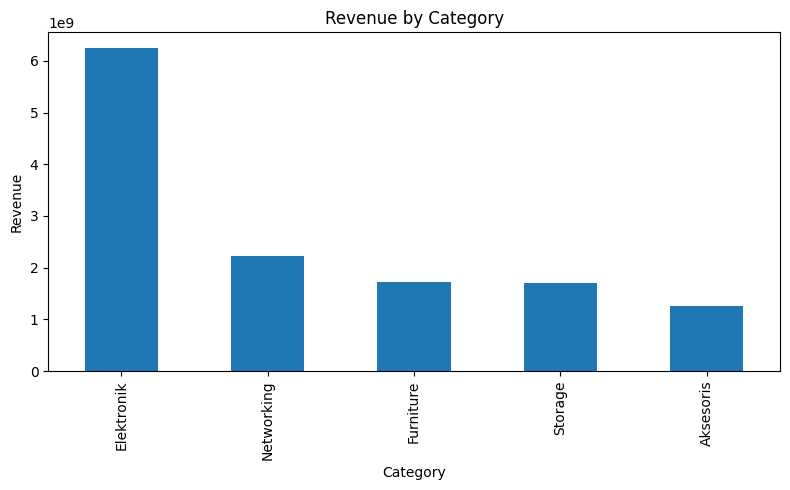

In [22]:
plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [23]:
# Top products by quantity
top_products = (
    df.groupby("Product")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

,Quantity
Product,
Hdd,485
Monitor,485
Keyboard,480
Headset,475
Router,464
Chair,458
Printer,458
Ssd,424
Flash Drive,418


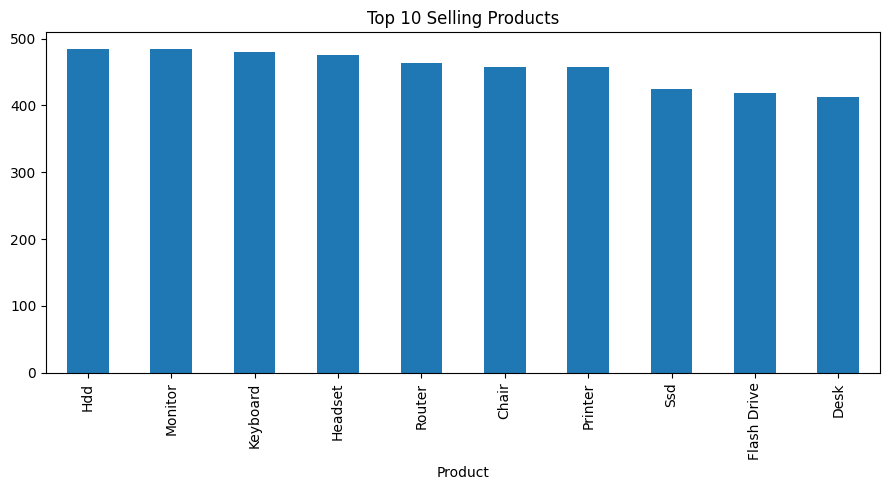

In [24]:
plt.figure(figsize=(9,5))
top_products.plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.tight_layout()
plt.show()

In [25]:
city_sales = (
    df.groupby("City")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
)

city_sales

,TotalPrice
City,
Makassar,1.374289e+09
Surabaya,1.372313e+09
Yogyakarta,1.345467e+09
Medan,1.342240e+09
Semarang,1.300730e+09
Jakarta,1.291738e+09
Palembang,1.269422e+09
Balikpapan,1.220073e+09
Bandung,1.212871e+09


In [26]:
payment = df["PaymentMethod"].value_counts()
payment

,count
PaymentMethod,
QRIS,503
Transfer Bank,490
E-Wallet,384
Kartu Kredit,346
COD,329
Unknown,43


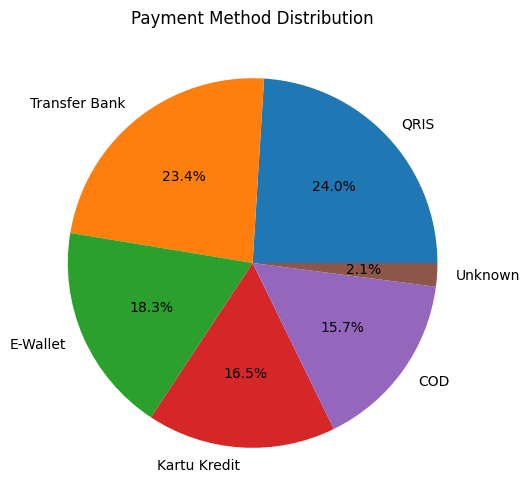

In [27]:
plt.figure(figsize=(6,6))
payment.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

In [28]:
monthly_sales = (
    df.groupby(df["OrderDate"].dt.to_period("M"))["TotalPrice"]
      .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)
monthly_sales

,TotalPrice
OrderDate,
2023-01,625308000.0
2023-02,577482000.0
2023-03,617661000.0
2023-04,481940000.0
2023-05,736614000.0
2023-06,447083000.0
2023-07,518738500.0
2023-08,533655000.0
2023-09,621216000.0


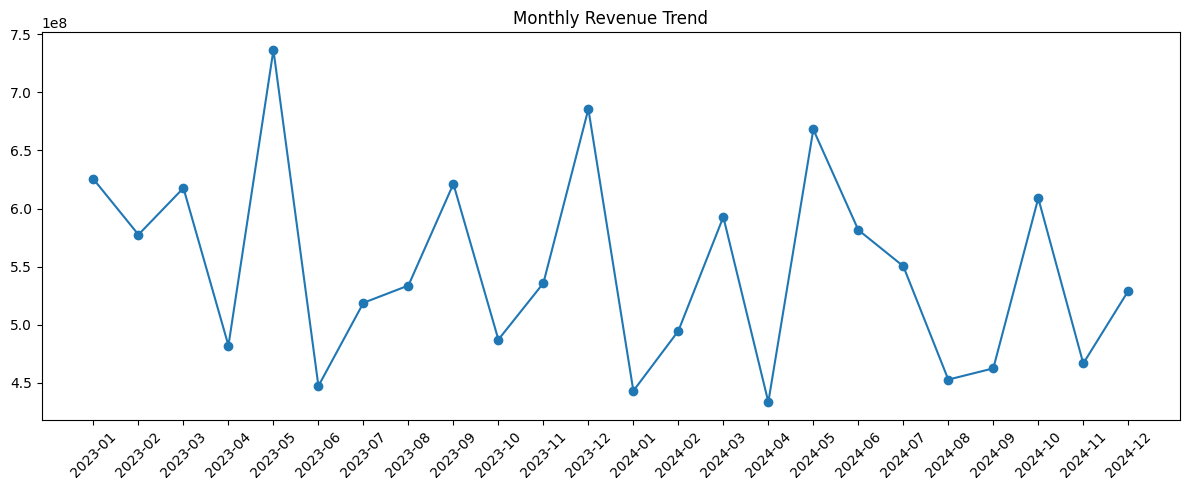

In [29]:
plt.figure(figsize=(12,5))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
plt.xticks(rotation=45)
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

In [30]:
status = df["OrderStatus"].value_counts()
status

,count
OrderStatus,
Pending,379
Cancelled,370
Shipped,358
Delivered,333
Paid,332
Returned,323


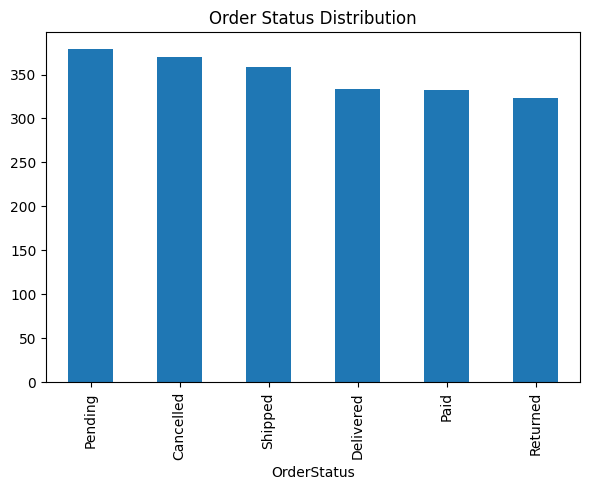

In [31]:
plt.figure(figsize=(6,5))
status.plot(kind="bar")
plt.title("Order Status Distribution")
plt.tight_layout()
plt.show()

In [32]:
traffic = (
    df["ReferralSource"]
    .value_counts()
)

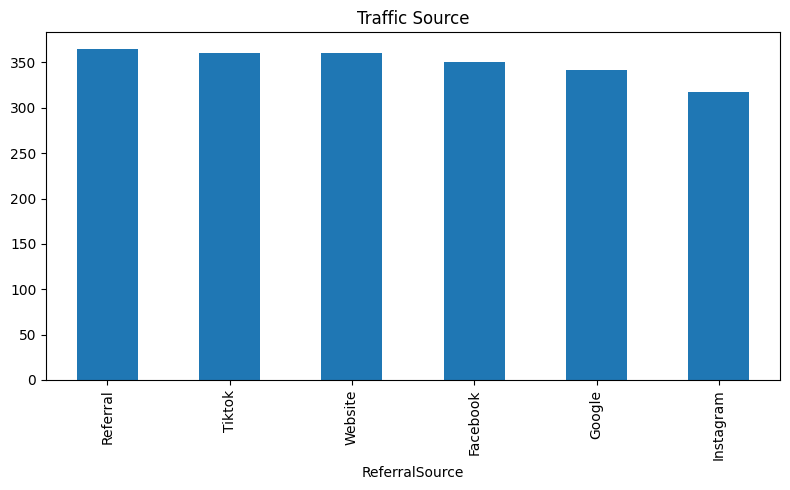

In [33]:
plt.figure(figsize=(8,5))
traffic.plot(kind="bar")
plt.title("Traffic Source")
plt.tight_layout()
plt.show()

In [34]:
# Calculate average order value
aov = df["TotalPrice"].mean()
print(f"Average Order Value : Rp {aov:,.0f}")

Average Order Value : Rp 6,277,257
